In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats, torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap, Normalize

sns.set(style='whitegrid', context='talk')

### helpers

In [ ]:
def set_seed(seed: int):
    # Reproducibility for python/numpy/torch RNGs
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_trials(n_stim=20, boundaries=(0.25, 0.5, 0.75), tail_eps=0.15):
    # Build full factorial trial table: each stimulus x each boundary
    # 20 equidistant points strictly inside (0,1)
    stim_values = np.linspace(0, 1, n_stim + 2, dtype=np.float32)[1:-1]

    rows = []
    for b in boundaries:
        for i, stim in enumerate(stim_values):
            cls = float(stim > b)  # binary class relative to boundary
            tail_mask = float((stim <= tail_eps) or (stim >= (1 - tail_eps)))  # edge stimuli flag
            rows.append(
                {
                    'boundary': float(b),
                    'boundary_label': f'b={b:.2f}',
                    'stim': float(stim),
                    'stim_idx': int(i),
                    'class': cls,
                    'tail_mask': tail_mask,
                }
            )

    return pd.DataFrame(rows)


def split_train_test(df, test_frac=0.2, seed=0):
    # Create deterministic RNG for reproducible splits
    rng = np.random.default_rng(seed)
    test_idx = []

    # Stratify by boundary so each condition contributes test samples
    # independently (prevents one boundary from dominating the test set).
    for _, grp in df.groupby('boundary'):
        idx = grp.index.to_numpy()
        rng.shuffle(idx)  # randomize order within this boundary group

        # Per-boundary test count (at least 1 row from each boundary).
        n_test = max(1, int(round(len(idx) * test_frac)))
        test_idx.extend(idx[:n_test])

    # Sort once for stable ordering; train is the complement of test indices.
    test_idx = np.array(sorted(test_idx))
    train_idx = df.index.difference(test_idx)

    # Return clean, reindexed dataframes for downstream tensor conversion.
    return (
        df.loc[train_idx].reset_index(drop=True),
        df.loc[test_idx].reset_index(drop=True),
    )


def df_to_tensors(df):
    # Convert dataframe columns into model input/target tensors
    X = torch.tensor(df[['stim', 'boundary']].values, dtype=torch.float32)
    y_class = torch.tensor(df[['class']].values, dtype=torch.float32)
    y_stim = torch.tensor(df[['stim']].values, dtype=torch.float32)
    y_bound = torch.tensor(df[['boundary']].values, dtype=torch.float32)
    y_tail = torch.tensor(df[['tail_mask']].values, dtype=torch.float32)
    return X, y_class, y_stim, y_bound, y_tail

### Generate data

In [16]:
# config
n_stim = 20
boundaries = (0.25, 0.5, 0.75)
n_nets = 30

# loss weights (descending priority)
class_wt = 1.0
stim_wt = 0.30
bound_wt = 0.15
tail_wt = 0.10

tail_eps = 0.15
use_train_test_split = True
test_frac = 0.20
base_seed = 20260302

# generate 60 unique trials
trials_df = make_trials(n_stim=n_stim, boundaries=boundaries, tail_eps=tail_eps)
assert len(trials_df) == 60

if use_train_test_split:
    train_df, test_df = split_train_test(trials_df, test_frac=test_frac, seed=base_seed)
else:
    train_df = trials_df.copy()
    test_df = trials_df.copy()

print(f'Total trials: {len(trials_df)} | Train: {len(train_df)} | Test: {len(test_df)}')
trials_df.head()

Total trials: 60 | Train: 48 | Test: 12


,boundary,boundary_label,stim,stim_idx,class,tail_mask
0,0.25,b=0.25,0.047619,0,0.0,1.0
1,0.25,b=0.25,0.095238,1,0.0,1.0
2,0.25,b=0.25,0.142857,2,0.0,1.0
3,0.25,b=0.25,0.190476,3,0.0,0.0
4,0.25,b=0.25,0.238095,4,0.0,0.0


### Organize data

In [17]:
# convert to tensors
X_train, y_class_train, y_stim_train, y_bound_train, y_tail_train = df_to_tensors(train_df)
X_test, y_class_test, y_stim_test, y_bound_test, y_tail_test = df_to_tensors(test_df)
X_full, y_class_full, y_stim_full, y_bound_full, y_tail_full = df_to_tensors(trials_df)

# class imbalance handling for BCE
pos_count = float(y_class_train.sum().item())
neg_count = float(len(y_class_train) - pos_count)
pos_weight = torch.tensor([neg_count / max(pos_count, 1.0)], dtype=torch.float32)

# data loaders
batch_size = 48
train_ds = TensorDataset(X_train, y_class_train, y_stim_train, y_bound_train, y_tail_train)
test_ds = TensorDataset(X_test, y_class_test, y_stim_test, y_bound_test, y_tail_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f'pos_weight for BCE: {pos_weight.item():.3f}')
train_loader, test_loader

pos_weight for BCE: 1.087


(<torch.utils.data.dataloader.DataLoader at 0x7f353ccbbfd0>,
 <torch.utils.data.dataloader.DataLoader at 0x7f353cc49210>)

### Train & Test

In [18]:
# training setup
max_epochs = 800   # hard cap — training always stops here even without convergence
min_epochs = 30    # burn-in period: convergence is not checked before this epoch
conv_target = 0.90 # rolling-window train accuracy that triggers early stopping
conv_window = 20   # number of recent epochs averaged to assess convergence
lr = 1e-2

network_results = []

for net_idx in range(n_nets):
    # Each network gets a unique but deterministic seed derived from the base seed,
    # so the ensemble is reproducible while each member is independently initialized.
    seed = base_seed + net_idx
    set_seed(seed)

    # Fresh model and optimizer for every network in the ensemble.
    model = BoundaryNet(in_dim=2, hidden_dim=10)
    optimizer = Adam(model.parameters(), lr=lr)

    network_epochs = []       # per-epoch stats for this network
    converged = False  # flag: did this network meet the early-stopping criterion?

    for epoch in range(max_epochs):
        # --- Training pass: gradients are computed and weights are updated. ---
        train_stats = run_epoch(model, train_loader, optimizer=optimizer, pos_weight=pos_weight)

        # --- Evaluation pass: no gradient updates, held-out test set only. ---
        test_stats = run_epoch(model, test_loader, optimizer=None, pos_weight=pos_weight)

        # Store both train and test stats for this epoch with prefixed keys.
        row = {
            'net_idx': net_idx,
            'seed': seed,
            'epoch': epoch,
            **{f"train_{k}": v for k, v in train_stats.items()},
            **{f"test_{k}": v for k, v in test_stats.items()},
        }
        network_epochs.append(row)

        # Early stopping check: only after burn-in and once enough epochs exists.
        if epoch >= min_epochs and len(network_epochs) >= conv_window:
            # Average train accuracy over the last `conv_window` epochs.
            recent_train_acc = np.mean([h['train_acc'] for h in network_epochs[-conv_window:]])
            if recent_train_acc >= conv_target:
                converged = True
                break  # exit the epoch loop; model is considered trained

    network_epochs_df = pd.DataFrame(network_epochs)

    # Final inference on every trial (including training trials) to get
    # a complete picture of the learned response function and hidden activations.
    full_pred_df, hidden_full, full_metrics = evaluate_model_on_df(model, trials_df, pos_weight=pos_weight)
    test_pred_df, hidden_test, test_metrics = evaluate_model_on_df(model, test_df, pos_weight=pos_weight)

    # Bundle everything for this network into a single dict so it can be accessed
    # uniformly when aggregating results across the ensemble.
    network_results.append(
        {
            'net_idx': net_idx,
            'seed': seed,
            'model': model,
            'epoch_results': network_epochs_df,
            'converged': converged,
            'epochs_ran': int(network_epochs_df['epoch'].max() + 1),
            'full_pred_df': full_pred_df,
            'test_pred_df': test_pred_df,
            'hidden_full': hidden_full,   # shape: [60, hidden_dim] — used for PCA
            'hidden_test': hidden_test,
            'full_metrics': full_metrics,
            'test_metrics': test_metrics,
        }
    )

nets_summarized_df = pd.DataFrame(
    {
        'net_idx': [net['net_idx'] for net in network_results],
        'seed': [net['seed'] for net in network_results],
        'converged': [net['converged'] for net in network_results],
        'epochs_ran': [net['epochs_ran'] for net in network_results],
        'test_acc': [net['test_metrics']['acc'] for net in network_results],
        'test_total_loss': [net['test_metrics']['total'] for net in network_results],
    }
)

nets_summarized_df.describe(include='all')

NameError: name 'BoundaryNet' is not defined

### Check results

In [ ]:
final_epoch_df = pd.DataFrame([r['history'].iloc[-1].to_dict() for r in runs])

print('Convergence rate:', ensemble_summary_df['converged'].mean())
print('Mean epochs run:', ensemble_summary_df['epochs_ran'].mean())
print('Mean test accuracy:', ensemble_summary_df['test_acc'].mean())
print('Std test accuracy:', ensemble_summary_df['test_acc'].std())

ensemble_summary_df.head()

Convergence rate: 1.0
Mean epochs run: 55.3
Mean test accuracy: 0.9805555555555556
Std test accuracy: 0.04736006476299462


,net_idx,seed,converged,epochs_ran,test_acc,test_total_loss
0,0,20260302,True,98,1.000000,0.323056
1,1,20260303,True,39,0.833333,0.664372
2,2,20260304,True,31,0.833333,0.669355
3,3,20260305,True,87,1.000000,0.413216
4,4,20260306,True,38,1.000000,0.601883


### Behavior

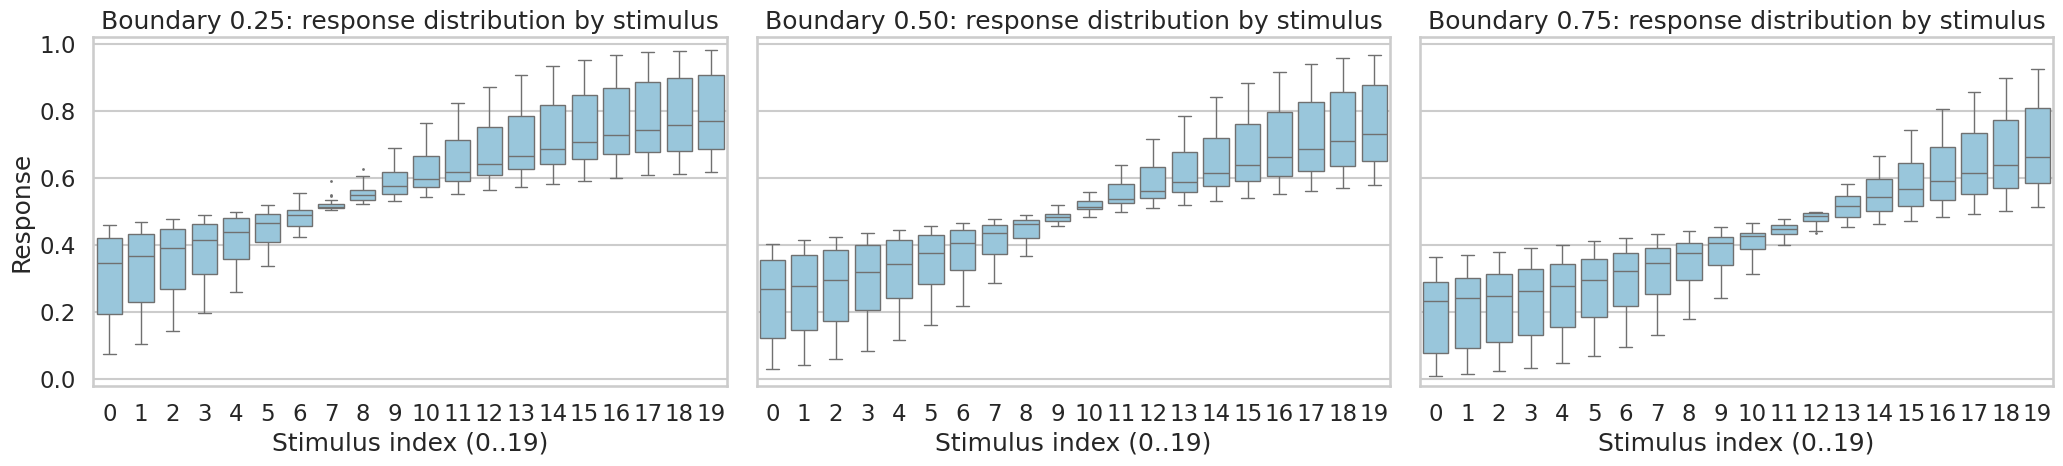

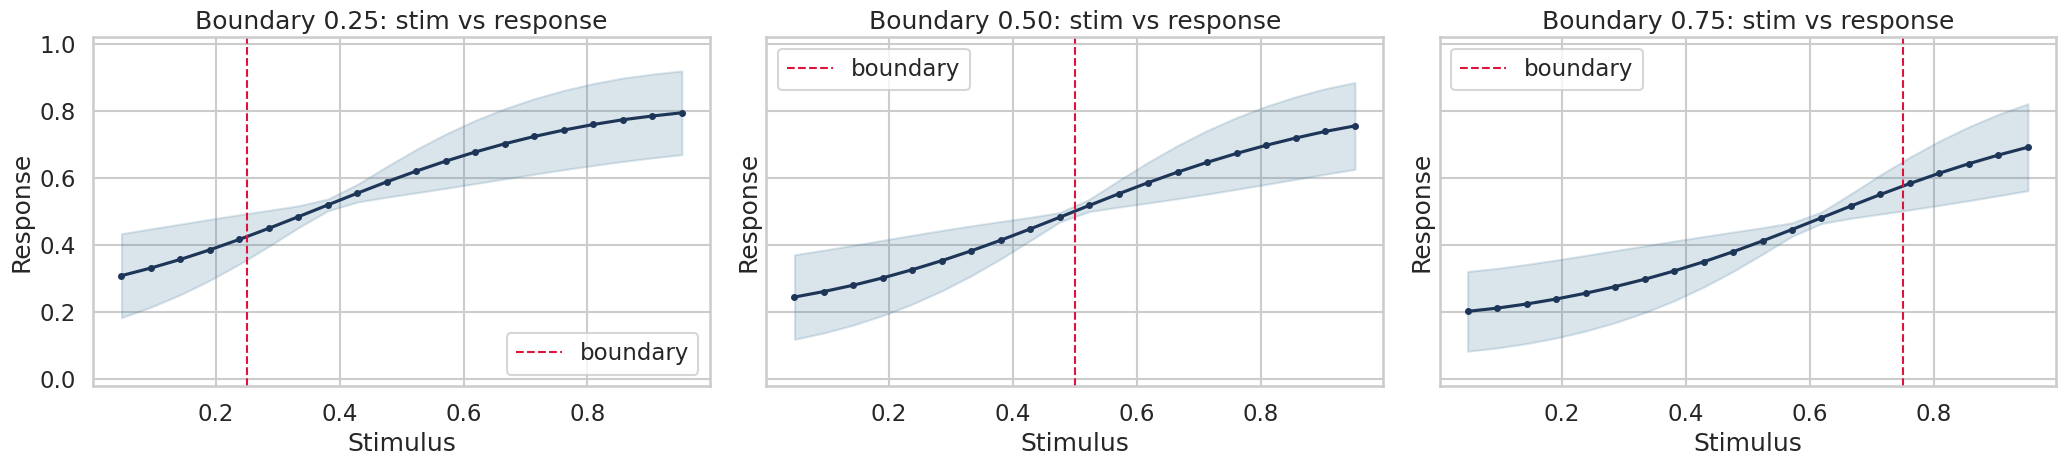

In [ ]:
# collect all network predictions on full 60-trial grid
beh_df = pd.concat(
    [r['full_pred_df'].assign(net_idx=r['net_idx']) for r in runs],
    ignore_index=True,
)

# (a) response distribution by stimulus, faceted by boundary
fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharey=True)
for ax, b in zip(axes, boundaries):
    sub = beh_df[beh_df['boundary'] == b].copy()
    sns.boxplot(data=sub, x='stim_idx', y='resp', ax=ax, color='#8ecae6', fliersize=1)
    ax.set_title(f'Boundary {b:.2f}: response distribution by stimulus')
    ax.set_xlabel('Stimulus index (0..19)')
    ax.set_ylabel('Response')
    ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

# (b) stim vs response, mean +/- std over networks
agg = (
    beh_df.groupby(['boundary', 'stim'], as_index=False)
    .agg(resp_mean=('resp', 'mean'), resp_std=('resp', 'std'))
)

fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharey=True)
for ax, b in zip(axes, boundaries):
    sub = agg[agg['boundary'] == b].sort_values('stim')
    ax.plot(sub['stim'], sub['resp_mean'], '-o', color='#1d3557', markersize=4)
    ax.fill_between(
        sub['stim'].values,
        (sub['resp_mean'] - sub['resp_std']).values,
        (sub['resp_mean'] + sub['resp_std']).values,
        alpha=0.2,
        color='#457b9d',
    )
    ax.axvline(b, ls='--', color='crimson', lw=1.5, label='boundary')
    ax.set_title(f'Boundary {b:.2f}: stim vs response')
    ax.set_xlabel('Stimulus')
    ax.set_ylabel('Response')
    ax.set_ylim(-0.02, 1.02)
    ax.legend(loc='best')
plt.tight_layout()
plt.show()

### Neural

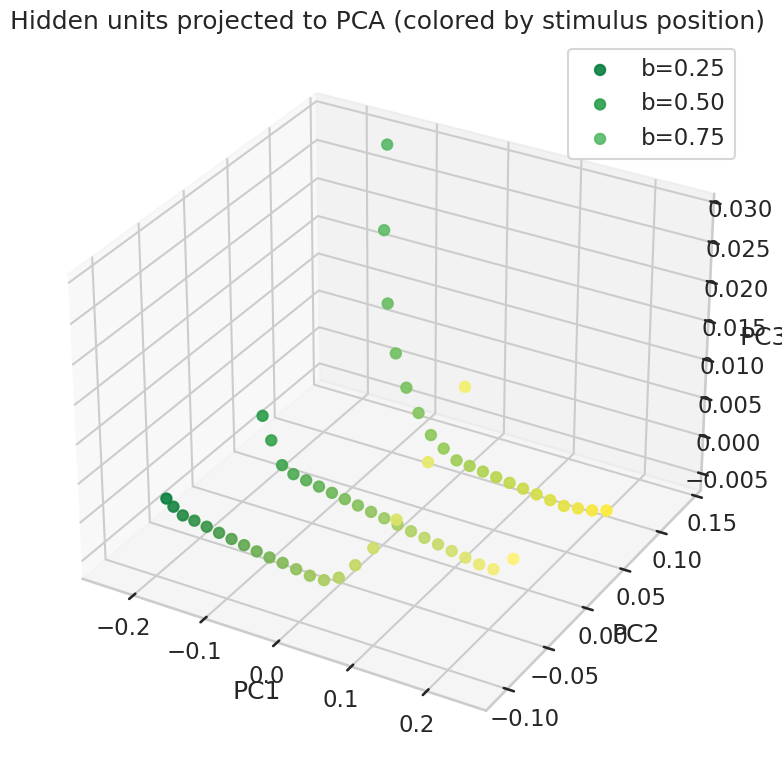

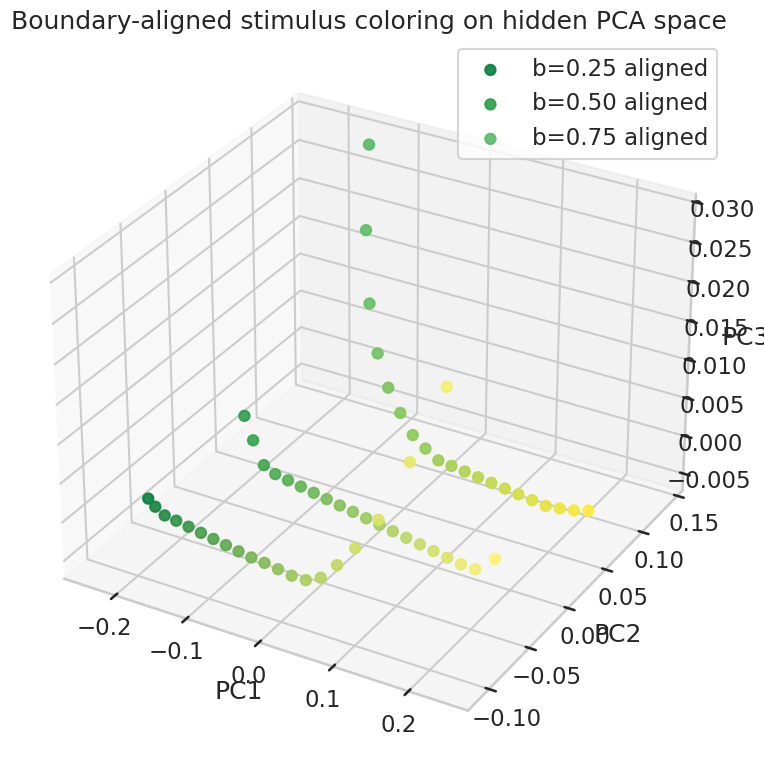

,boundary,bound_pos
0,0.25,0.047619
1,0.50,0.047619
2,0.75,0.047619


In [ ]:
# average hidden activations across networks for each of the 60 trials
hidden_stack = np.stack([r['hidden_full'] for r in runs], axis=0)  # [n_nets, 60, 10]
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]

# project to 3 PCs
pca = PCA(n_components=3)
pcs = pca.fit_transform(hidden_mean)

pca_df = trials_df.copy()
pca_df['PC1'] = pcs[:, 0]
pca_df['PC2'] = pcs[:, 1]
pca_df['PC3'] = pcs[:, 2]

# three green->yellow spectra (one per boundary)
cond_cmaps = {
    0.25: LinearSegmentedColormap.from_list('gy_025', ['#0a7f3f', '#f3ef6d']),
    0.50: LinearSegmentedColormap.from_list('gy_050', ['#2c9e4b', '#fff176']),
    0.75: LinearSegmentedColormap.from_list('gy_075', ['#59b96a', '#ffeb3b']),
}

# plot 1: PCA with color encoding stimulus position within each condition
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for b in boundaries:
    sub = pca_df[pca_df['boundary'] == b].sort_values('stim')
    norm = Normalize(vmin=sub['stim'].min(), vmax=sub['stim'].max())
    colors = cond_cmaps[b](norm(sub['stim'].values))

    ax.scatter(sub['PC1'], sub['PC2'], sub['PC3'], c=colors, s=55, alpha=0.9, label=f'b={b:.2f}')

ax.set_title('Hidden units projected to PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# boundary-align stimulus positions
# bound_pos = Euclidean distance between the two stimuli that flank each boundary.
bound_pos = {}
for b in boundaries:
    stim_vals = np.sort(pca_df.loc[pca_df['boundary'] == b, 'stim'].unique())
    lower = stim_vals[stim_vals < b].max()
    upper = stim_vals[stim_vals > b].min()
    bound_pos[b] = float(np.linalg.norm(np.array([upper - lower])))

pca_df['stim_aligned'] = pca_df['stim'] - pca_df['boundary'].map(bound_pos)

# plot 2: re-plot with aligned stimulus-position coloring
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for b in boundaries:
    sub = pca_df[pca_df['boundary'] == b].sort_values('stim_aligned')
    norm = Normalize(vmin=sub['stim_aligned'].min(), vmax=sub['stim_aligned'].max())
    colors = cond_cmaps[b](norm(sub['stim_aligned'].values))

    ax.scatter(sub['PC1'], sub['PC2'], sub['PC3'], c=colors, s=55, alpha=0.9, label=f'b={b:.2f} aligned')

ax.set_title('Boundary-aligned stimulus coloring on hidden PCA space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

pd.DataFrame({'boundary': list(bound_pos.keys()), 'bound_pos': list(bound_pos.values())})